# Twitter Sentiment Analysis — Baseline, LSTM, and Attention

In this notebook I work through sentiment classification on a Twitter dataset
(3 classes: negative / neutral / positive). The idea is to start simple and
build up:

1. **Baseline** — TF-IDF + Logistic Regression. The classical NLP go-to. Fast, cheap, surprisingly strong.
2. **Word2Vec + LSTM** — learn word embeddings on the training data, then feed them into a PyTorch LSTM.
3. **BiLSTM + Attention** — same embeddings but a richer architecture: bidirectional recurrence and an attention layer that learns which words matter.

Along the way: EDA, cleaning, consistent metrics (accuracy, macro-F1, confusion matrices), and training curves for the neural models.


## 1. Setup

In [28]:
import os
import re
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

from gensim.models import Word2Vec

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 2. Dataset

Using the Twitter sentiment dataset from Kaggle (`saurabhshahane/twitter-sentiment-dataset`).
The snippet below just makes sure the file is available locally — if not, it pulls it via `kagglehub`.

In [29]:
from __future__ import annotations

import csv
import math
import shutil
from collections import defaultdict

DATASET_DIR = Path.cwd() / "dataset"
DATASET_PATH = DATASET_DIR / "Twitter_Data.csv"
LABEL_NAMES = {-1: "negative", 0: "neutral", 1: "positive"}
RANDOM_SEED = 42

random.seed(RANDOM_SEED)

def ensure_dataset() -> Path:
    if DATASET_PATH.exists():
        print(f"Using existing dataset: {DATASET_PATH}")
        return DATASET_PATH

    try:
        import kagglehub
    except ImportError as exc:
        raise ImportError(
            "Dataset not found locally. Install kagglehub or place Twitter_Data.csv in dataset/."
        ) from exc

    DATASET_DIR.parent.mkdir(parents=True, exist_ok=True)
    cache_path = Path(kagglehub.dataset_download("saurabhshahane/twitter-sentiment-dataset")).resolve()
    archive_cache_path = cache_path if cache_path.name.endswith(".archive") else cache_path.with_name(f"{cache_path.name}.archive")

    if DATASET_DIR.exists():
        shutil.rmtree(DATASET_DIR)

    shutil.copytree(cache_path, DATASET_DIR)
    print(f"Downloaded dataset to: {DATASET_DIR}")

    if archive_cache_path.exists():
        shutil.rmtree(archive_cache_path)
        print(f"Deleted Kaggle archive cache: {archive_cache_path}")
    elif cache_path.exists() and ".cache" in str(cache_path):
        shutil.rmtree(cache_path)
        print(f"Deleted Kaggle cache: {cache_path}")

    return DATASET_PATH


dataset_path = ensure_dataset()
dataset_path

Using existing dataset: h:\Personal Project\twitter_sentiment_analysis\dataset\Twitter_Data.csv


WindowsPath('h:/Personal Project/twitter_sentiment_analysis/dataset/Twitter_Data.csv')

In [30]:
df = pd.read_csv(dataset_path)
print("shape:", df.shape)
print("columns:", list(df.columns))
df.head()

shape: (162980, 2)
columns: ['clean_text', 'category']


,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [31]:
# the dataset has a few rows with NaN in text or label — drop them
df = df.dropna(subset=["clean_text", "category"]).reset_index(drop=True)
df["category"] = df["category"].astype(int)
print("after dropna:", df.shape)
df["category"].value_counts().rename(LABEL_NAMES)

after dropna: (162969, 2)


category
positive    72249
neutral     55211
negative    35509
Name: count, dtype: int64

## 3. Quick EDA

Before modelling, a couple of things I want to know:
- Are the classes balanced?
- How long are the tweets? Does length differ by sentiment?
- Do the examples actually look like what I expect?

Nothing fancy — just enough to avoid building a model on top of surprises.

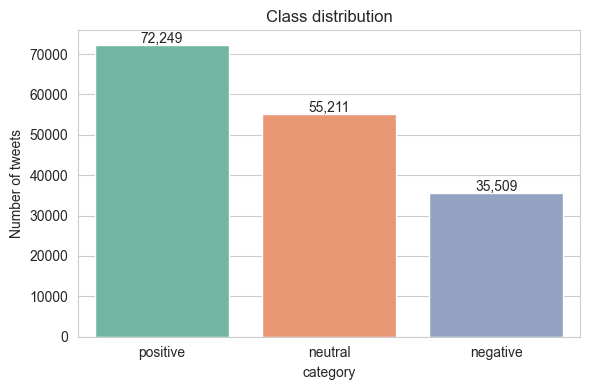

In [32]:
# class distribution
counts = df["category"].map(LABEL_NAMES).value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, palette="Set2", ax=ax)
ax.set_title("Class distribution")
ax.set_ylabel("Number of tweets")
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f"{v:,}", ha="center")
plt.tight_layout()
plt.show()

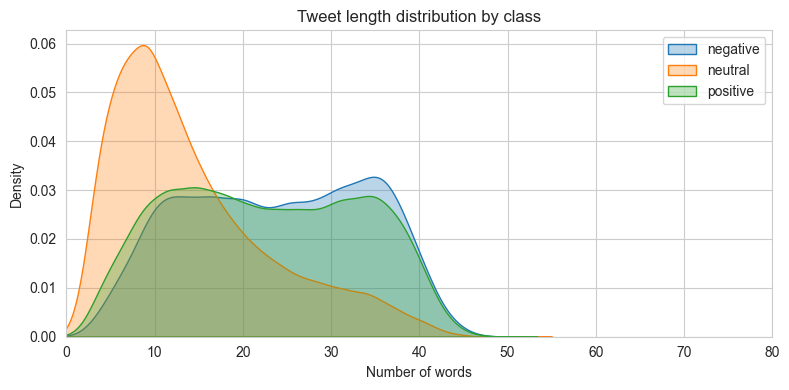

count    162969.000000
mean         20.080702
std          10.879596
min           0.000000
25%          11.000000
50%          18.000000
75%          29.000000
max          52.000000
Name: n_words, dtype: float64

In [33]:
# text length (in words) per class
df["n_words"] = df["clean_text"].astype(str).str.split().str.len()

plt.figure(figsize=(8, 4))
for cat, name in LABEL_NAMES.items():
    sns.kdeplot(
        df.loc[df["category"] == cat, "n_words"],
        label=name, fill=True, alpha=0.3,
    )
plt.xlim(0, 80)
plt.xlabel("Number of words")
plt.title("Tweet length distribution by class")
plt.legend()
plt.tight_layout()
plt.show()

df["n_words"].describe()

In [34]:
# a handful of raw examples per class
for cat, name in LABEL_NAMES.items():
    print(f"\n--- {name.upper()} ---")
    for text in df.loc[df["category"] == cat, "clean_text"].sample(3, random_state=SEED):
        print(f" - {str(text)[:150]}")


--- NEGATIVE ---
 - desperately waiting watch the not movie review upcoming narendra modi please the first day release 
 - madam kanpur and akbarpur seat will loose candidates having very bad image there modi alone cannot make such the extent the damage done present mps ne
 - everything that happened under nehru gandhi due their vision and selflessness whereas everything that happened under modi also due nehru gandhi vision

--- NEUTRAL ---
 - hating modi congress undermining matters national interest are dealing with allies pakistan
 - besides attack was not planned modi has just given permission was combined efforts nsa and indian army but nor expect indian communist have any sympat
 - only modi can protect nations borders you all are pakistani agent

--- POSITIVE ---
 - this nyay scheme the retrd will game changer for sure most people voted for modi 2014 with hopes getting lakhs their account the mindset poor our coun
 - special thanks for recognising work done yers congress rule d

## 4. Preprocessing

The `clean_text` column has already been partly processed, but I still want to:
- lowercase everything
- drop URLs and @mentions (they rarely carry sentiment)
- strip the `#` from hashtags but keep the word (often the topic is useful)
- remove non-alphabetic junk
- drop rows that end up with almost no content

In [35]:
URL_RE = re.compile(r"http\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
NON_ALPHA_RE = re.compile(r"[^a-z\s']")
MULTI_SPACE_RE = re.compile(r"\s+")

def clean_tweet(text: str) -> str:
    text = text.lower()
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = text.replace("#", " ")     # keep the word, drop the hash
    text = NON_ALPHA_RE.sub(" ", text)
    text = MULTI_SPACE_RE.sub(" ", text).strip()
    return text

df["text"] = df["clean_text"].astype(str).apply(clean_tweet)

# drop tweets that are too short after cleaning — they're usually useless
df = df[df["text"].str.split().str.len() >= 2].reset_index(drop=True)
print("final shape:", df.shape)
df[["clean_text", "text", "category"]].head()

final shape: (162673, 4)


,clean_text,text,category
0,when modi promised “minimum government maximum...,when modi promised minimum government maximum ...,-1
1,talk all the nonsense and continue all the dra...,talk all the nonsense and continue all the dra...,0
2,what did just say vote for modi welcome bjp t...,what did just say vote for modi welcome bjp to...,1
3,asking his supporters prefix chowkidar their n...,asking his supporters prefix chowkidar their n...,1
4,answer who among these the most powerful world...,answer who among these the most powerful world...,1


## 5. Train / val / test split

Stratified, because the neutral class is the largest and I want each split to reflect the real distribution.

In [36]:
X = df["text"].values
y = df["category"].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, random_state=SEED, stratify=y_trainval
)
print(f"train={len(X_train):,}  val={len(X_val):,}  test={len(X_test):,}")

train=117,531  val=20,741  test=24,401


## 6. Baseline — TF-IDF + Logistic Regression

The idea of a baseline is to have a number to beat. TF-IDF on unigrams + bigrams
with logistic regression is a classic for a reason: it trains in seconds and
sets a meaningful floor for everything that follows.

In [37]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    min_df=2,
    sublinear_tf=True,
)
Xtr_tfidf = tfidf.fit_transform(X_train)
Xva_tfidf = tfidf.transform(X_val)
Xte_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix:", Xtr_tfidf.shape)

lr = LogisticRegression(max_iter=1000, C=1.0, n_jobs=-1)
lr.fit(Xtr_tfidf, y_train)

val_pred = lr.predict(Xva_tfidf)
test_pred_baseline = lr.predict(Xte_tfidf)

print(f"\nVal  acc : {accuracy_score(y_val, val_pred):.4f}")
print(f"Test acc : {accuracy_score(y_test, test_pred_baseline):.4f}")
print(f"Test F1  : {f1_score(y_test, test_pred_baseline, average='macro'):.4f}")
print()
print(classification_report(
    y_test, test_pred_baseline,
    target_names=[LABEL_NAMES[-1], LABEL_NAMES[0], LABEL_NAMES[1]],
))

TF-IDF matrix: (117531, 50000)

Val  acc : 0.9117
Test acc : 0.9099
Test F1  : 0.8987

              precision    recall  f1-score   support

    negative       0.92      0.78      0.84      5325
     neutral       0.89      0.97      0.93      8247
    positive       0.93      0.93      0.93     10829

    accuracy                           0.91     24401
   macro avg       0.91      0.89      0.90     24401
weighted avg       0.91      0.91      0.91     24401



## 7. Word2Vec + LSTM

Now the fun part. Two steps:
1. Train a Word2Vec model on the training tweets to get 100-dim word vectors.
2. Feed sequences of embeddings into a small LSTM classifier in PyTorch.

I use skip-gram (`sg=1`) because with short tweets it tends to behave better on rare-ish words.

In [38]:
tokens_train = [t.split() for t in X_train]

w2v = Word2Vec(
    sentences=tokens_train,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,            # skip-gram
    seed=SEED,
    epochs=5,
)
print(f"Vocab size: {len(w2v.wv):,}")

# sanity check — nearest neighbours should look reasonable
for w in ["good", "bad", "india"]:
    if w in w2v.wv:
        print(f"\n{w} -> {[x for x, _ in w2v.wv.most_similar(w, topn=5)]}")

Vocab size: 32,720

good -> ['gud', 'bad', 'apt', 'doer', 'useful']

bad -> ['good', 'useful', 'mouthing', 'gud', 'taste']

india -> ['modiindia', 'country', 'bcm', 'indiamodi', 'dimension']


In [39]:
# build the vocab + embedding matrix used by the PyTorch model
# idx 0 = <pad>, idx 1 = <unk>
PAD_IDX, UNK_IDX = 0, 1
vocab = {"<pad>": PAD_IDX, "<unk>": UNK_IDX}
for word in w2v.wv.key_to_index:
    vocab[word] = len(vocab)

embedding_dim = 100
emb_matrix = np.random.normal(0, 0.1, (len(vocab), embedding_dim)).astype(np.float32)
emb_matrix[PAD_IDX] = 0.0
for word, idx in vocab.items():
    if word in w2v.wv:
        emb_matrix[idx] = w2v.wv[word]

print(f"Embedding matrix shape: {emb_matrix.shape}")

Embedding matrix shape: (32722, 100)


In [40]:
# our labels are -1, 0, 1 — map them to 0, 1, 2 for the neural models
LABEL2IDX = {-1: 0, 0: 1, 1: 2}
IDX2LABEL = {v: k for k, v in LABEL2IDX.items()}

def to_idx(arr):
    return np.array([LABEL2IDX[int(v)] for v in arr])

y_train_idx = to_idx(y_train)
y_val_idx   = to_idx(y_val)
y_test_idx  = to_idx(y_test)

In [41]:
# dataset + collate for variable-length sequences
MAX_LEN = 40   # most tweets are well under this

def encode(text):
    ids = [vocab.get(w, UNK_IDX) for w in text.split()[:MAX_LEN]]
    if not ids:
        ids = [UNK_IDX]  # safety — shouldn't happen after our filtering
    return torch.tensor(ids, dtype=torch.long)

class TweetDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, i):
        return encode(self.texts[i]), int(self.labels[i])

def collate(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    padded = pad_sequence(seqs, batch_first=True, padding_value=PAD_IDX)
    return padded, lengths, torch.tensor(labels, dtype=torch.long)

BATCH = 256
train_ds = TweetDataset(X_train, y_train_idx)
val_ds   = TweetDataset(X_val,   y_val_idx)
test_ds  = TweetDataset(X_test,  y_test_idx)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True, collate_fn=collate)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, collate_fn=collate)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, collate_fn=collate)

In [42]:
class LSTMClassifier(nn.Module):
    """Plain LSTM over pre-trained word2vec embeddings -> linear classifier."""
    def __init__(self, emb_weights, hidden=128, n_classes=3, dropout=0.4):
        super().__init__()
        self.emb = nn.Embedding.from_pretrained(
            torch.tensor(emb_weights), freeze=False, padding_idx=PAD_IDX,
        )
        self.lstm = nn.LSTM(emb_weights.shape[1], hidden, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, n_classes)

    def forward(self, x, lengths):
        emb = self.emb(x)
        packed = pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h, _) = self.lstm(packed)
        return self.fc(self.drop(h.squeeze(0)))

In [43]:
def train_model(model, train_dl, val_dl, epochs=4, lr=1e-3):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        # ---- train ----
        model.train()
        total = 0.0
        for x, lengths, y in train_dl:
            x, lengths, y = x.to(DEVICE), lengths.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            logits = model(x, lengths)
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()
            total += loss.item() * x.size(0)
        train_loss = total / len(train_dl.dataset)

        # ---- validate ----
        model.eval()
        vloss, correct, n = 0.0, 0, 0
        with torch.no_grad():
            for x, lengths, y in val_dl:
                x, lengths, y = x.to(DEVICE), lengths.to(DEVICE), y.to(DEVICE)
                logits = model(x, lengths)
                vloss += loss_fn(logits, y).item() * x.size(0)
                correct += (logits.argmax(1) == y).sum().item()
                n += x.size(0)
        val_loss, val_acc = vloss / n, correct / n

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")
    return history


def predict(model, dl):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, lengths, y in dl:
            x, lengths = x.to(DEVICE), lengths.to(DEVICE)
            preds.append(model(x, lengths).argmax(1).cpu().numpy())
            trues.append(y.numpy())
    return np.concatenate(preds), np.concatenate(trues)

In [44]:
lstm_model = LSTMClassifier(emb_matrix)
lstm_history = train_model(lstm_model, train_dl, val_dl, epochs=10)

Epoch 1: train_loss=0.5376  val_loss=0.2313  val_acc=0.9265
Epoch 2: train_loss=0.1717  val_loss=0.1538  val_acc=0.9567
Epoch 3: train_loss=0.1078  val_loss=0.1317  val_acc=0.9628
Epoch 4: train_loss=0.0743  val_loss=0.1138  val_acc=0.9671
Epoch 5: train_loss=0.0606  val_loss=0.1176  val_acc=0.9687
Epoch 6: train_loss=0.0424  val_loss=0.1232  val_acc=0.9675
Epoch 7: train_loss=0.0338  val_loss=0.1389  val_acc=0.9663
Epoch 8: train_loss=0.0276  val_loss=0.1563  val_acc=0.9650
Epoch 9: train_loss=0.0273  val_loss=0.1560  val_acc=0.9670
Epoch 10: train_loss=0.0192  val_loss=0.1643  val_acc=0.9656


In [45]:
lstm_preds, lstm_trues = predict(lstm_model, test_dl)
print(f"Test acc: {accuracy_score(lstm_trues, lstm_preds):.4f}")
print(f"Test F1 : {f1_score(lstm_trues, lstm_preds, average='macro'):.4f}\n")
print(classification_report(
    lstm_trues, lstm_preds,
    target_names=["negative", "neutral", "positive"],
))

Test acc: 0.9636
Test F1 : 0.9600

              precision    recall  f1-score   support

    negative       0.95      0.93      0.94      5325
     neutral       0.98      0.97      0.98      8247
    positive       0.96      0.98      0.97     10829

    accuracy                           0.96     24401
   macro avg       0.96      0.96      0.96     24401
weighted avg       0.96      0.96      0.96     24401



## 8. BiLSTM + Attention

Two upgrades over the previous model:

**Bidirectional LSTM.** The network now reads the tweet both left-to-right and
right-to-left, so each token's representation sees context on both sides.

**Attention.** Instead of using just the final hidden state, we compute a weighted
sum over every timestep. The weights are learned. This is the same pattern that
motivates self-attention in transformers, just in a simpler form (additive attention à la Bahdanau).

Mathematically, for hidden states $h_1,\dots,h_T$:

$$
e_t = v^\top \tanh(W h_t), \quad
\alpha_t = \frac{\exp(e_t)}{\sum_{t'} \exp(e_{t'})}, \quad
c = \sum_t \alpha_t\, h_t
$$

The classifier sits on top of the context vector $c$.

In [46]:
class Attention(nn.Module):
    """Additive attention: score = v^T tanh(W h)."""
    def __init__(self, hidden):
        super().__init__()
        self.W = nn.Linear(hidden, hidden)
        self.v = nn.Linear(hidden, 1, bias=False)

    def forward(self, outputs, mask):
        # outputs: (B, T, H)  mask: (B, T) bool, True = real token
        scores = self.v(torch.tanh(self.W(outputs))).squeeze(-1)      # (B, T)
        scores = scores.masked_fill(~mask, float("-inf"))
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)           # (B, T, 1)
        context = (outputs * weights).sum(dim=1)                       # (B, H)
        return context, weights.squeeze(-1)


class BiLSTMAttn(nn.Module):
    def __init__(self, emb_weights, hidden=128, n_classes=3, dropout=0.4):
        super().__init__()
        self.emb = nn.Embedding.from_pretrained(
            torch.tensor(emb_weights), freeze=False, padding_idx=PAD_IDX,
        )
        self.lstm = nn.LSTM(
            emb_weights.shape[1], hidden,
            batch_first=True, bidirectional=True,
        )
        self.attn = Attention(hidden * 2)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, n_classes)

    def forward(self, x, lengths):
        mask = (x != PAD_IDX)
        emb = self.emb(x)
        packed = pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        out, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(out, batch_first=True)

        # pad_packed_sequence trims to the longest sequence in the batch, so trim the mask too
        mask = mask[:, :out.size(1)]

        ctx, _ = self.attn(out, mask)
        return self.fc(self.drop(ctx))

In [47]:
bilstm_model = BiLSTMAttn(emb_matrix)
bilstm_history = train_model(bilstm_model, train_dl, val_dl, epochs=10)

Epoch 1: train_loss=0.3938  val_loss=0.1281  val_acc=0.9636
Epoch 2: train_loss=0.0947  val_loss=0.0848  val_acc=0.9741
Epoch 3: train_loss=0.0582  val_loss=0.0794  val_acc=0.9775
Epoch 4: train_loss=0.0433  val_loss=0.0907  val_acc=0.9744
Epoch 5: train_loss=0.0334  val_loss=0.0962  val_acc=0.9744
Epoch 6: train_loss=0.0239  val_loss=0.1044  val_acc=0.9757
Epoch 7: train_loss=0.0186  val_loss=0.1111  val_acc=0.9731
Epoch 8: train_loss=0.0141  val_loss=0.1300  val_acc=0.9714
Epoch 9: train_loss=0.0111  val_loss=0.1330  val_acc=0.9716
Epoch 10: train_loss=0.0092  val_loss=0.1395  val_acc=0.9707


In [48]:
bilstm_preds, bilstm_trues = predict(bilstm_model, test_dl)
print(f"Test acc: {accuracy_score(bilstm_trues, bilstm_preds):.4f}")
print(f"Test F1 : {f1_score(bilstm_trues, bilstm_preds, average='macro'):.4f}\n")
print(classification_report(
    bilstm_trues, bilstm_preds,
    target_names=["negative", "neutral", "positive"],
))

Test acc: 0.9689
Test F1 : 0.9664

              precision    recall  f1-score   support

    negative       0.95      0.95      0.95      5325
     neutral       0.98      0.98      0.98      8247
    positive       0.97      0.97      0.97     10829

    accuracy                           0.97     24401
   macro avg       0.97      0.97      0.97     24401
weighted avg       0.97      0.97      0.97     24401



## 9. Training curves

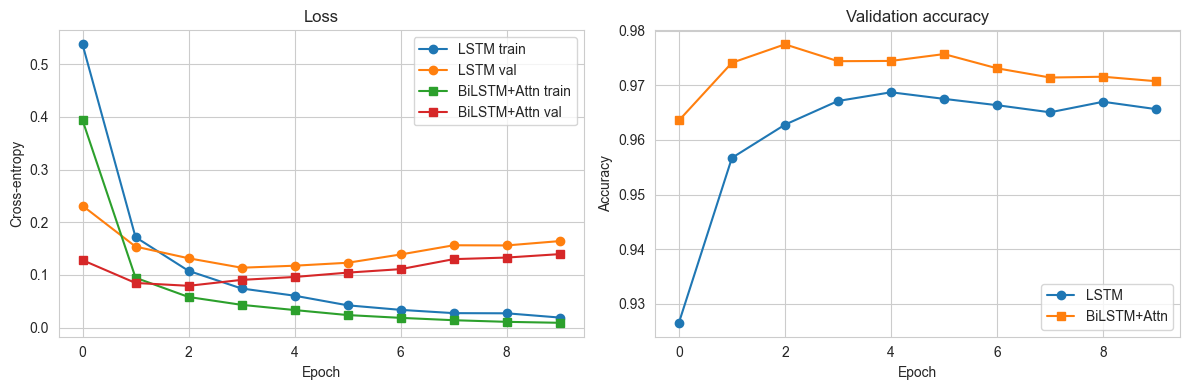

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lstm_history["train_loss"],   label="LSTM train",        marker="o")
axes[0].plot(lstm_history["val_loss"],     label="LSTM val",          marker="o")
axes[0].plot(bilstm_history["train_loss"], label="BiLSTM+Attn train", marker="s")
axes[0].plot(bilstm_history["val_loss"],   label="BiLSTM+Attn val",   marker="s")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy")
axes[0].legend()

axes[1].plot(lstm_history["val_acc"],   label="LSTM",        marker="o")
axes[1].plot(bilstm_history["val_acc"], label="BiLSTM+Attn", marker="s")
axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Putting it all together

Same test set, three models, same metrics.

In [50]:
# align indexing: baseline is in {-1, 0, 1}, neural models are in {0, 1, 2}
baseline_trues_idx = to_idx(y_test)
baseline_preds_idx = to_idx(test_pred_baseline)

models = {
    "TF-IDF + LogReg":    (baseline_trues_idx, baseline_preds_idx),
    "Word2Vec + LSTM":    (lstm_trues,   lstm_preds),
    "BiLSTM + Attention": (bilstm_trues, bilstm_preds),
}

summary = pd.DataFrame([
    {
        "model": name,
        "accuracy": accuracy_score(t, p),
        "macro_f1": f1_score(t, p, average="macro"),
    }
    for name, (t, p) in models.items()
])
summary

,model,accuracy,macro_f1
0,TF-IDF + LogReg,0.909922,0.898689
1,Word2Vec + LSTM,0.963608,0.960036
2,BiLSTM + Attention,0.968936,0.966378


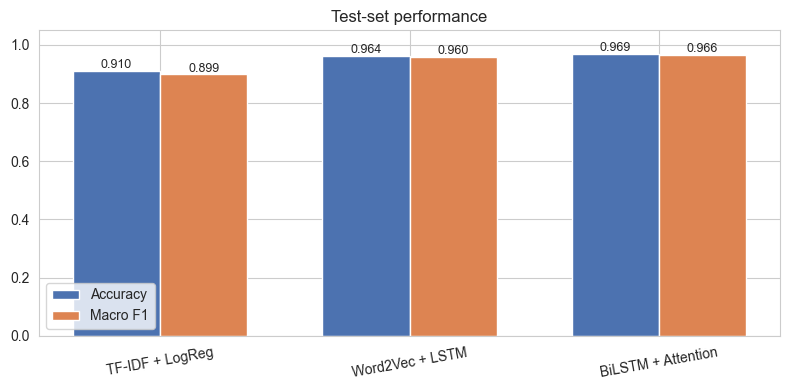

In [51]:
# bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(summary))
w = 0.35
bars1 = ax.bar(x - w/2, summary["accuracy"], w, label="Accuracy",  color="#4C72B0")
bars2 = ax.bar(x + w/2, summary["macro_f1"], w, label="Macro F1",  color="#DD8452")
for bars in (bars1, bars2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f"{b.get_height():.3f}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(summary["model"], rotation=10)
ax.set_ylim(0, 1.05)
ax.set_title("Test-set performance")
ax.legend()
plt.tight_layout()
plt.show()

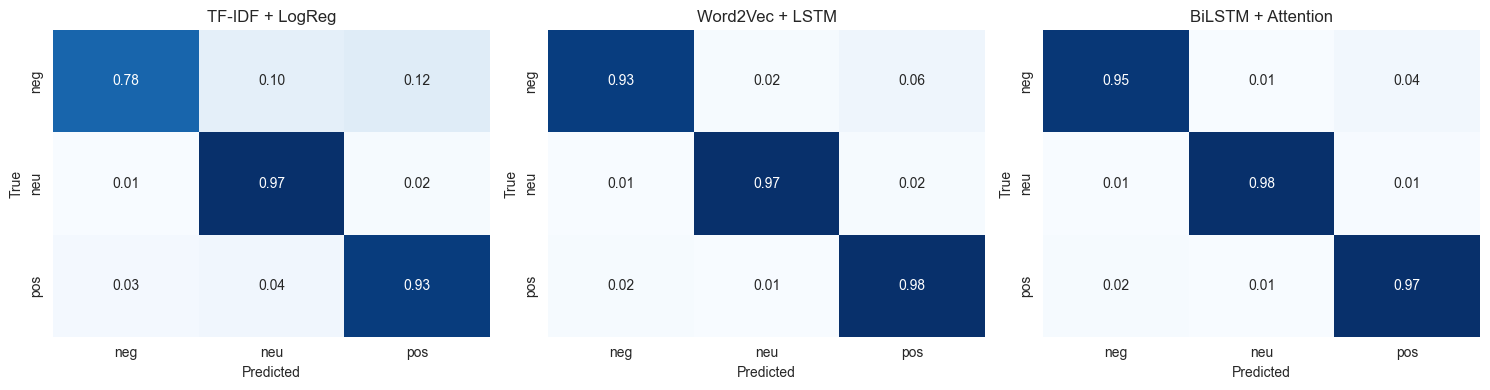

In [52]:
# normalised confusion matrices, side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (t, p)) in zip(axes, models.items()):
    cm = confusion_matrix(t, p)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=["neg", "neu", "pos"],
        yticklabels=["neg", "neu", "pos"],
        ax=ax, cbar=False,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.show()

## 11. What I learned / next steps

A few things that tend to show up in this kind of setup:

- **The TF-IDF baseline is surprisingly strong.** With bigrams and a linear classifier, it's often within a few points of the neural models on clean, medium-sized datasets. Always worth running first.
- **The LSTM benefits from pre-trained word2vec.** Initialising the embedding matrix with skip-gram vectors beats training them from random, especially on words that appear only a few times in the training data.
- **Attention helps, and it's interpretable.** The weights `alpha_t` can be inspected to see which tokens the model actually used. This is the same intuition that led to transformers.

**Natural next steps if I extend this:**

- Fine-tune **DistilBERT** on the same splits. Pre-trained transformers usually take another 2–4 points of F1 on Twitter-style data without much tuning.
- Do **error analysis** on the confusion matrix off-diagonals — which neutrals get called positive, and why?
- Try **class weights** in the loss to push back on the imbalance.
- Hyperparameter search on hidden size, dropout, learning rate.
